In [25]:
from sage.all import *


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return tr

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)

        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return results

precision=20
N = 1
for k in range(2,60):
    index=-1
    S = Newforms(N, k, names='a')
    if len(S) >0:
        gos=galois_orbit_sum(N,k,precision)
        for sm in gos:
            for f in sm:
                print(gos[f])

[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420]


IndexError: list index out of range

In [18]:
N=1
for k in range(2,61):
nf = Newforms(N, k, names='a')
for index in range(0,len(nf)):
    print("index:",index)
    f = nf[index]
    expansion = f.q_expansion(401)
    coeffs = [expansion[n] for n in range(1, 401)]
    print(coeffs[:20])
    print()


index: 0
[1, a0, -4*a0 + 3, 2*a0 - 6, 8*a0 - 7, -5*a0 - 8, -4*a0 + 14, -10*a0 + 4, 8*a0 + 14, 9*a0 + 16, -11, 14*a0 - 34, -20*a0 + 60, 6*a0 - 8, -12*a0 - 85, -32*a0 + 28, 12*a0 - 74, 30*a0 + 16, 60*a0 - 24, -30*a0 + 74]



In [17]:
S = CuspForms(11, 4)
f = S.newforms(names='a')[0]
K = f.base_ring()
poly = K.polynomial()
print(poly.roots(ring=SR, multiplicities=False)) # <<<<<<< the generators

[-sqrt(3) + 1, sqrt(3) + 1]


In [ ]:
``In what sense do these generators generate the field?

``In the sense that every element of the field Q(a0) can be written as a polynomial in a0 with rational coefficients. That is, every element has the form
\[
c_0 + c_1 a_0 + c_2 a_0^2 + \cdots + c_{d-1} a_0^{d-1}
\]
where c0,c1,…,cd−1∈Q and 
d is the degree of the minimal polynomial. The minimal polynomial is what allows you to reduce any higher power of a0 back down to degree less than dd
d --- for example in the weight-4 level-11 case, a02=2a0+2a_0^2 = 2a_0 + 2
a02​=2a0​+2, so nothing of degree 2 or higher ever appears irreducibly.

So the field is just Q extended by one algebraic number a_0
and that single number is enough to reach everything in the field by rational arithmetic operations.


In [17]:
# this inputs level as N, weight as k, desired dinensjon as dim and finds those N such 
# that fit the description.
from sage.all import *
k = 4
dim = 3
lst=[]

for N in range(1, 500):
    S = CuspForms(N, k)
    d = S.dimension()
    if d ==dim:
        lst.append(N)
print(lst)

[10, 12, 13, 16]


In [6]:
S = CuspForms(10, 4)
f = S.newforms(names='a')[0]
K = f.base_ring()
poly = K.polynomial()
print(poly.roots(ring=SR, multiplicities=False)) # <<<<<<< the generators
print(K.degree())

[0]
1


In [1]:
from sage.all import *
import pickle
precision=400



def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)[0]
       
        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return (results)

N=1
k=16
gos=galois_orbit_sum(N, k, precision)
print(len(gos))
print()
print(gos[0][:30])
print(gos[0][1:30])
print("len(gos):",len(gos))

1

[0, 1, 216, -3348, 13888, 52110, -723168, 2822456, -4078080, -3139803, 11255760, 20586852, -46497024, -190073338, 609650496, -174464280, -1335947264, 1646527986, -678197448, 1563257180, 723703680, -9449582688, 4446760032, 9451116072, 13653411840, -27802126025, -41055841008, 58552201080, 39198268928, -36902568330]
[1, 216, -3348, 13888, 52110, -723168, 2822456, -4078080, -3139803, 11255760, 20586852, -46497024, -190073338, 609650496, -174464280, -1335947264, 1646527986, -678197448, 1563257180, 723703680, -9449582688, 4446760032, 9451116072, 13653411840, -27802126025, -41055841008, 58552201080, 39198268928, -36902568330]
len(gos): 1


('j_list', 20)
('j_list', 40)
('j_list', 60)
('j_list', 80)
('j_list', 100)
('j_list', 120)
('j_list', 140)
('j_list', 160)
('j_list', 180)
('j_list', 200)
('j_list', 220)
('j_list', 240)
('j_list', 260)
('j_list', 280)
('j_list', 300)
('j_list', 320)
('j_list', 340)
('j_list', 360)
('j_list', 380)
('j_list', 400)
(1, 0.0022346854209899904)
(2, 0.0031143863995869952)
(3, 0.0035515546798706053)
(4, 0.0036612669626871746)
(5, 0.0037732521692911782)
(6, 0.003802037239074707)
(7, 0.003829920291900635)
(8, 0.0038715998331705728)
(9, 0.003922001520792643)
(10, 0.00397111972173055)
(11, 0.0040304342905680334)
(12, 0.004093050956726074)
(13, 0.004178035259246826)
(14, 0.004280702273050944)
(15, 0.0044089516003926596)
(16, 0.004546519120534261)
(17, 0.004713519414265951)
(18, 0.00487746795018514)
(19, 0.005059500535329183)
(20, 0.005268152554829915)
(21, 0.005481215318044027)
(22, 0.005792351563771566)
(23, 0.006111570199330648)
(24, 0.00657568375269572)
(25, 0.006923699378967285)
(26, 0.007350

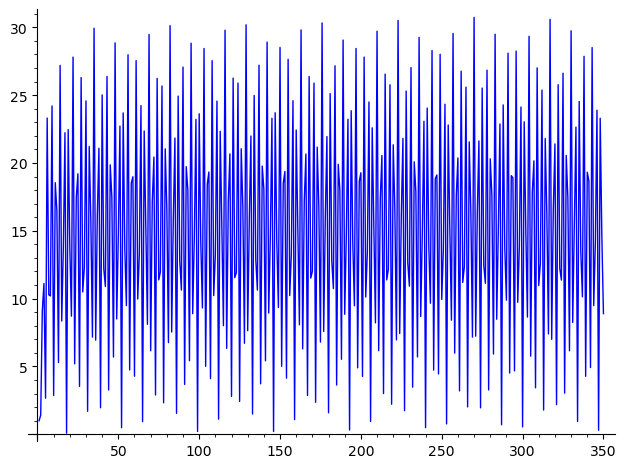

In [4]:
from sage.all import *
from sage.all import *
import pickle
import time


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)[0]
       
        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return (results)

start=time.time()

N=1
k=16

   
        
precision=500 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)


indexed_list=[(n,gos[0][n]) for n in range(1,len(gos[0]))] # n >= 1 drops the constant term
cffs=[pair[1] for pair in indexed_list]

h_list=[1]+cffs
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in range(1,n):
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    j_list.append((n,j_n))
    if n%20==0:
        print(("j_list",n))
    





with open('/Users/barrybrent/data2/run13apr26no11.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile) 
    
with open('/Users/barrybrent/data2/run13apr26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable


charpol_list=[]
roots_list=[]

mins_list=[]


for n in range(1, 351):
    now=time.time()
    elapsed=(now-start)/60
    print((n,elapsed))
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run13apr26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run13apr26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run13apr26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped